In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Legacy EV only knows classical algorithms
legacy_ev = {
    "name": "Legacy EV",
    "key_exchange": ["RSA"],
    "signatures": ["ECDSA"],
}

# Modern EV supports both classical and post-quantum
modern_ev = {
    "name": "Modern EV",
    "key_exchange": ["Kyber", "RSA"],
    "signatures": ["Dilithium", "ECDSA"],
}

# Charging stations
legacy_station = {
    "name": "Legacy Charging Station",
    "key_exchange": ["RSA"],
    "signatures": ["ECDSA"],
}

hybrid_station = {
    "name": "Hybrid Charging Station",
    "key_exchange": ["Kyber", "RSA"],
    "signatures": ["Dilithium", "ECDSA"],
}

pqc_station = {
    "name": "PQC-Only Station",
    "key_exchange": ["Kyber"],
    "signatures": ["Dilithium", "SPHINCS+"],
}

print("Legacy EV supports:", legacy_ev["key_exchange"], legacy_ev["signatures"])
print("Modern EV supports:", modern_ev["key_exchange"], modern_ev["signatures"])

Legacy EV supports: ['RSA'] ['ECDSA']
Modern EV supports: ['Kyber', 'RSA'] ['Dilithium', 'ECDSA']


In [31]:
# Post-quantum algorithm names
PQC_KEY_EXCHANGE = ["Kyber"]
PQC_SIGNATURES = ["Dilithium", "SPHINCS+"]


def pick_algorithm(ev_list, station_list, preferred_order):
    # Go through preferred order and return the first one both sides have
    for algo in preferred_order:
        if algo in ev_list and algo in station_list:
            return algo
    return None


def negotiate(ev, station):
    # Preferred order: post-quantum first, then classical fallback
    key_order  = ["Kyber", "RSA"]
    signature_order = ["Dilithium", "SPHINCS+", "ECDSA"]

    chosen_key  = pick_algorithm(ev["key_exchange"], station["key_exchange"], key_order)
    chosen_signature = pick_algorithm(ev["signatures"],   station["signatures"],   signature_order)

    # If either side has no common algorithm the session cannot start
    if chosen_key is None or chosen_signature is None:
        return {
            "ev": ev["name"],
            "station": station["name"],
            "status": "rejected",
            "key_exchange": None,
            "signature": None,
            "mode": "incompatible",
        }

    # Check if the result is classical, hybrid or full post-quantum
    key_is_pqc  = chosen_key  in PQC_KEY_EXCHANGE
    signature_is_pqc = chosen_signature in PQC_SIGNATURES

    if key_is_pqc and signature_is_pqc:
        mode = "post-quantum"
    elif key_is_pqc or signature_is_pqc:
        mode = "hybrid"
    else:
        mode = "classical only"

    return {
        "ev": ev["name"],
        "station": station["name"],
        "status": "accepted",
        "key_exchange": chosen_key,
        "signature": chosen_signature,
        "mode": mode,
    }


# Test with a simple example
result = negotiate(modern_ev, hybrid_station)
print(result)

{'ev': 'Modern EV', 'station': 'Hybrid Charging Station', 'status': 'accepted', 'key_exchange': 'Kyber', 'signature': 'Dilithium', 'mode': 'post-quantum'}


In [32]:
# Run all EV + station combinations
scenarios = [
    (legacy_ev,  legacy_station),
    (legacy_ev,  hybrid_station),
    (modern_ev,  hybrid_station),
    (modern_ev,  pqc_station),
    (legacy_ev,  pqc_station),
]

results = []
for ev, station in scenarios:
    r = negotiate(ev, station)
    results.append(r)
    print(r["ev"], "<->", r["station"], ":", r["status"], "-", r["mode"])

Legacy EV <-> Legacy Charging Station : accepted - classical only
Legacy EV <-> Hybrid Charging Station : accepted - classical only
Modern EV <-> Hybrid Charging Station : accepted - post-quantum
Modern EV <-> PQC-Only Station : accepted - post-quantum
Legacy EV <-> PQC-Only Station : rejected - incompatible


In [ ]:
# Organize data into a Pandas DataFrame for analysis and display
data = {
    "Algorithm": ["RSA", "ECDSA", "Kyber", "Dilithium", "SPHINCS+"],
    "PQC": [False, False, True, True, True],
    "Latency(ms)": [8, 4, 12, 18, 310],
    "PubKey(B)": [256, 64, 1184, 1312, 32],
    "Sig/Ciph(B)": [256, 64, 1088, 2420, 7856]
}

df = pd.DataFrame(data)
display(df)


,Algorithm,PQC,Latency(ms),PubKey(B),Sig/Ciph(B)
0,RSA,False,8,256,256
1,ECDSA,False,4,64,64
2,Kyber,True,12,1184,1088
3,Dilithium,True,18,1312,2420
4,SPHINCS+,True,310,32,7856


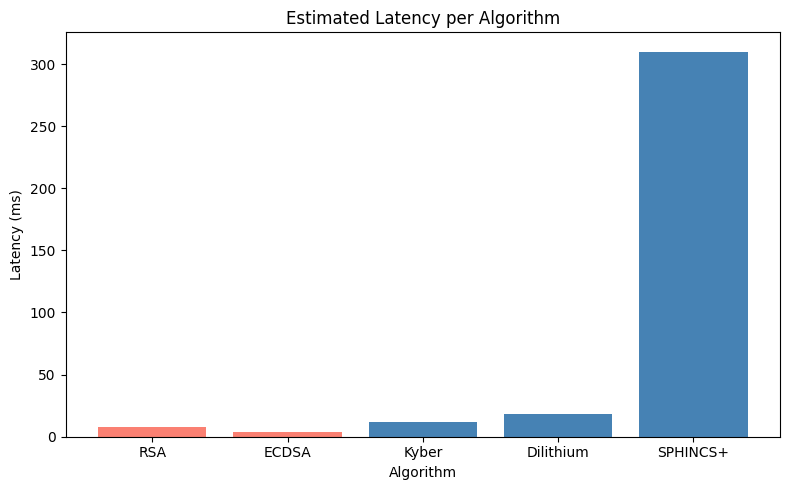

Red = classical, Blue = post-quantum


In [28]:
# Color bars differently for classical vs post-quantum
colors = ["steelblue" if is_pqc else "salmon" for is_pqc in df["PQC"]]

plt.figure(figsize=(8, 5))
plt.bar(df["Algorithm"], df["Latency(ms)"], color=colors)
plt.title("Estimated Latency per Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Latency (ms)")
plt.tight_layout()
plt.show()

print("Red = classical, Blue = post-quantum")


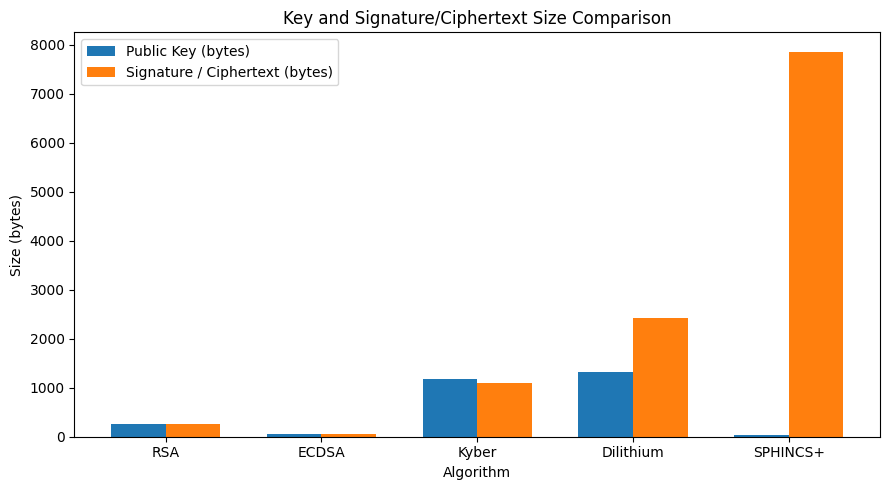

In [33]:
# Grouped bar chart for key sizes and signature/ciphertext sizes
x = range(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Shift bars left and right so they don't overlap
bars1 = ax.bar([i - width/2 for i in x], df["PubKey(B)"],  width, label="Public Key (bytes)")
bars2 = ax.bar([i + width/2 for i in x], df["Sig/Ciph(B)"], width, label="Signature / Ciphertext (bytes)")

ax.set_title("Key and Signature/Ciphertext Size Comparison")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Size (bytes)")
ax.set_xticks(list(x))
ax.set_xticklabels(df["Algorithm"])
ax.legend()

plt.tight_layout()
plt.show()
